<a href="https://colab.research.google.com/github/amanmeka/DataScience/blob/main/Unit5/AmanMekaU5proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 5 Project: Basketball Rookie Analysis


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
from scipy.interpolate import PchipInterpolator

In [ ]:
bball = "https://raw.githubusercontent.com/amanmeka/DataScience/refs/heads/main/NBA%20Rookies%20by%20Year.csv"

For this project I decided to analyze how FGA plays a role in FTA. It would make sense if there is a correlation because if there are more FGA there is a higher cahnce of more FTA mainly because they might get fouled on the drive.

In [ ]:
bball = pd.read_csv(bball)

In [ ]:
bball

,index,Name,Year Drafted,GP,MIN,PTS,FGM,FGA,FG%,3P Made,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,EFF
0,0,Brandon Ingram,2016.0,36.0,27.4,7.4,2.6,7.6,34.7,0.5,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,7.3
1,1,Andrew Harrison,2016.0,35.0,26.9,7.2,2.0,6.7,29.6,0.7,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,7.9
2,2,Rodney McGruder,2016.0,30.0,25.7,5.8,2.1,5.3,40.0,0.8,...,1.0,72.4,1.5,2.0,3.5,1.5,0.7,0.3,0.7,7.5
3,3,Joel Embiid,2016.0,22.0,24.8,18.9,6.2,13.4,46.4,1.2,...,6.8,77.3,2.0,5.4,7.3,1.9,0.8,2.4,3.8,18.8
4,4,Dario Saric,2016.0,32.0,24.1,9.5,3.5,9.0,38.7,1.3,...,1.7,77.4,1.2,4.7,5.9,1.7,0.5,0.2,1.8,10.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
bball = bball.dropna(subset=['Name'])

In [ ]:
bball

,index,Name,Year Drafted,GP,MIN,PTS,FGM,FGA,FG%,3P Made,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,EFF
0,0,Brandon Ingram,2016.0,36.0,27.4,7.4,2.6,7.6,34.7,0.5,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,7.3
1,1,Andrew Harrison,2016.0,35.0,26.9,7.2,2.0,6.7,29.6,0.7,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,7.9
2,2,Rodney McGruder,2016.0,30.0,25.7,5.8,2.1,5.3,40.0,0.8,...,1.0,72.4,1.5,2.0,3.5,1.5,0.7,0.3,0.7,7.5
3,3,Joel Embiid,2016.0,22.0,24.8,18.9,6.2,13.4,46.4,1.2,...,6.8,77.3,2.0,5.4,7.3,1.9,0.8,2.4,3.8,18.8
4,4,Dario Saric,2016.0,32.0,24.1,9.5,3.5,9.0,38.7,1.3,...,1.7,77.4,1.2,4.7,5.9,1.7,0.5,0.2,1.8,10.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1533,1533,Billy Reid,1980.0,59.0,10.1,3.2,1.4,3.1,45.4,0.0,...,0.7,56.4,0.5,0.6,1.0,1.2,0.6,0.1,1.3,2.8
1534,1534,Jerry Sichting,1980.0,47.0,9.6,2.0,0.7,2.0,35.8,0.0,...,0.7,78.1,0.2,0.7,0.9,1.5,0.5,0.0,0.6,2.9
1535,1535,Reggie Carter,1980.0,60.0,8.9,2.8,1.0,3.0,33.0,0.0,...,1.2,73.9,0.5,0.7,1.2,1.3,0.4,0.0,0.6,2.7
1536,1536,Mike Harper,1980.0,55.0,8.4,2.7,1.0,2.5,41.2,0.0,...,1.5,43.5,0.5,1.2,1.7,0.3,0.4,0.4,0.6,2.6


In [ ]:
#lb stands for linear bike
with pm.Model() as model_lb:

    #priors for the linear part of our model
    α = pm.Normal("α", mu=0, sigma=100)
    β = pm.Normal("β", mu=0, sigma=10)

    #this is the linear part of our model
    μ = pm.Deterministic("μ", α + β * bball.FGA)

    #prior for the standard deviation of our likelihood
    #Cauchy is a T dist with nu = 1
    σ = pm.HalfCauchy("σ", 10)

    #likelihood
    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=bball.FTA)

    #inference data object
    idata_lb = pm.sample()

array([<Axes: title={'center': 'α'}>, <Axes: title={'center': 'β'}>,
       <Axes: title={'center': 'σ'}>], dtype=object)

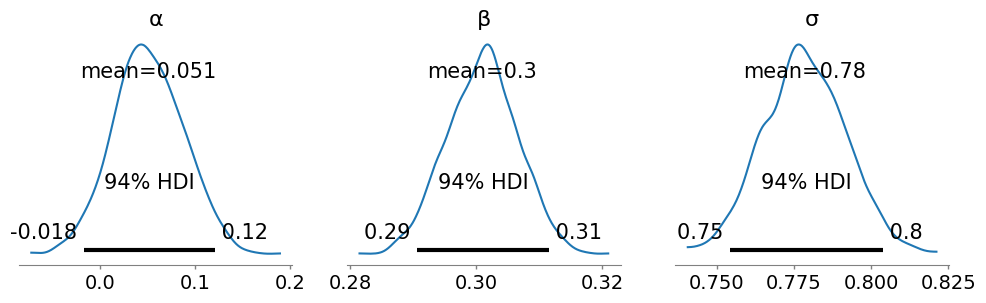

In [ ]:
#plot of the posteriors for all the components of my line
#'~μ' means plot all variables except μ
az.plot_posterior(idata_lb, var_names=["~μ"], figsize=(12, 3))

In [ ]:
#lb stands for linear bike
with pm.Model() as model_lb:

    #priors for the linear part of our model
    α = pm.Normal("α", mu=0, sigma=100)
    β = pm.Normal("β", mu=0, sigma=10)

    #this is the linear part of our model
    μ = pm.Deterministic("μ", α + β * bball.FGA)

    #prior for the standard deviation of our likelihood
    #Cauchy is a T dist with nu = 1
    σ = pm.HalfCauchy("σ", 10)

    #likelihood
    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=bball.FTA)

    #inference data object
    idata_lb = pm.sample()

Text(0, 0.5, 'FTA')

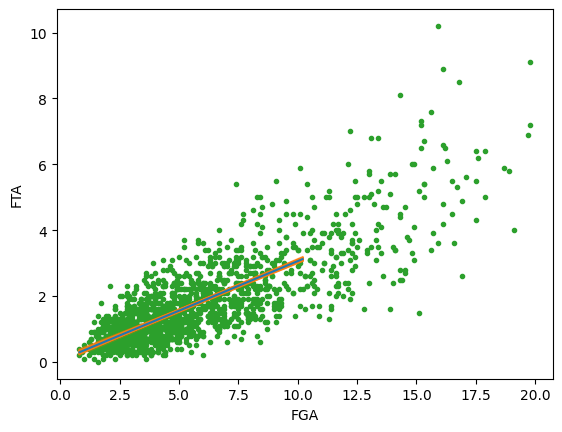

In [ ]:
#grabs 100 posterior samples
posterior = az.extract(idata_lb, num_samples=100)

# grabbing x values for graphing.
x_plot = xr.DataArray(
    np.linspace(bball.FGA.min(), bball.FTA.max(), 50),
    dims="plot_id"
    )

# this creates the expected line, the path we predict temperature and
#rented bike count deviates from
mean_line = posterior["α"].mean() + posterior["β"].mean() * x_plot

#These are a 50 lines that our model came up with
lines = posterior["α"] + posterior["β"] * x_plot

#set up plot
_, ax = plt.subplots()

#plots 50 other lines our model came up with.
ax.plot(x_plot, lines.T, c="C1", alpha=0.2, label="lines")

#plots the mean line
ax.plot(x_plot, mean_line, c="C0", label="mean line")

#plot the raw data
ax.plot(bball.FGA, bball.FTA, "C2.", zorder=-3)

#label axes and create legend
ax.set_xlabel("FGA")
ax.set_ylabel("FTA")

It seems like the linear regression fits the data pretty well.

Text(0, 0.5, 'FTA')

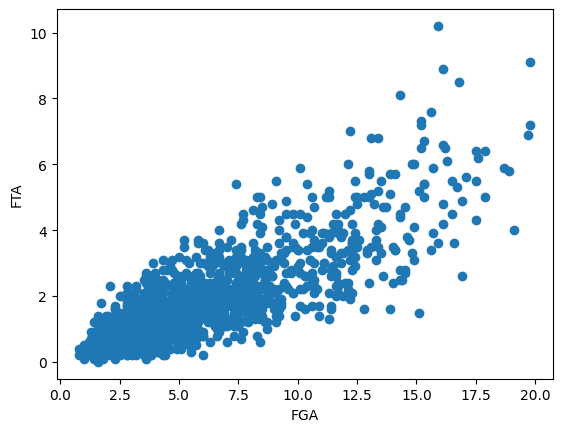

In [ ]:
#make scatter plot of FT% and FG% for NBA rookie players
plt.scatter(bball['FGA'] , bball['FTA'],)

#label axes
plt.xlabel("FGA")
plt.ylabel("FTA")

In [ ]:
# posterior predictive check
pm.sample_posterior_predictive(idata_lb, model=model_lb,  extend_inferencedata=True)

Text(0, 0.5, 'rented bikes')

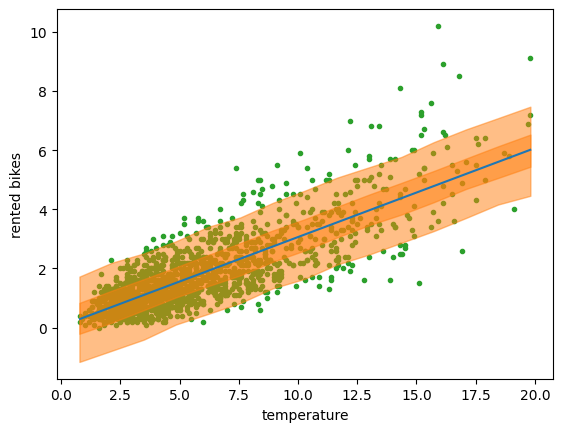

In [ ]:
#plots the posterior predictive distribution

#grabs the expected line, or line of best fit formula
mean_line = idata_lb.posterior["μ"].mean(("chain", "draw"))

#creates some x values to run through our line formula
temperatures = np.random.normal(bball.FGA.values, 0.01)
idx = np.argsort(temperatures)
x = np.linspace(temperatures.min(), temperatures.max(), 15)

#grabs the 94% HDI and 50% HDI, and sets them up for graphing.
y_pred_q = idata_lb.posterior_predictive["y_pred"].quantile(
    [0.03, 0.97, 0.25, 0.75], dim=["chain", "draw"]
)
y_hat_bounds = iter(
    [
        PchipInterpolator(temperatures[idx], y_pred_q[i][idx])(x)
        for i in range(4)
    ]
)

#plots raw data and our line of best fit
_, ax = plt.subplots()
ax.plot(bball.FGA, bball.FTA, "C2.", zorder=-3)
ax.plot(bball.FGA[idx], mean_line[idx], c="C0")


#graphs the 94% and 50% HDIs
for lb, ub in zip(y_hat_bounds, y_hat_bounds):
    ax.fill_between(x, lb, ub, color="C1", alpha=0.5)

#labels
ax.set_xlabel("temperature")
ax.set_ylabel("rented bikes")

<Axes: xlabel='y_pred'>

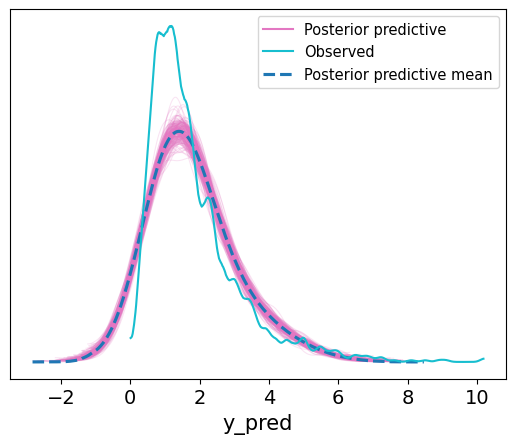

In [ ]:
#posterior predictive check
az.plot_ppc(idata_lb, num_pp_samples=200, colors=["C6", "C9", "C0"])

### Conclusion:

It looks like the posterior predictive fits the observed data decently except for the one peak at the start of the observed data.